In [17]:
%matplotlib notebook
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
import os, sys

module_path = os.path.abspath(os.path.join("../.."))
sys.path.append(module_path)

## Dataset and hyperparameters loading

In [19]:
import torch
from torchvision.transforms.v2 import Compose

from SLTDataset import SLTDataset
from posecraft.Pose import Pose
from helpers import create_src_mask
from hyperparameters import load_hyperparameters_from_json


DATASET = "GSL"
EXPERIMENT_ID = "happy-salad-43"
SAMPLE_IDX = 27

dataset_path = f"/mnt/disk3Tb/slt-datasets/{DATASET}"
experiment_path = f"results/{DATASET}/{EXPERIMENT_ID}"
hp = load_hyperparameters_from_json(f"{experiment_path}/hp.json")
output_path = f"{experiment_path}/interp/samples/{SAMPLE_IDX}"
os.makedirs(output_path, exist_ok=True)
transparent_plot = False

landmarks_mask = Pose.get_components_mask(hp["LANDMARKS_USED"])
transforms: Compose = Compose(hp["TRANSFORMS"])

test_dataset = SLTDataset(
    data_dir=dataset_path,
    split="test",
    input_mode=hp["INPUT_MODE"],
    output_mode=hp["OUTPUT_MODE"],
    transforms=transforms,
    max_tokens=hp["MAX_TOKENS"],
)

Loaded metadata for dataset: The Greek Sign Language (GSL) Dataset
Loaded test annotations at /mnt/disk3Tb/slt-datasets/GSL/annotations.csv


Validating files: 100%|██████████| 881/881 [00:00<00:00, 246115.75it/s]

Dataset loaded correctly



### Display sample

In [20]:
from IPython.display import HTML

# avoid using the last transform as it flattens the keypoints
visual_transforms: Compose = Compose(hp["TRANSFORMS"][:-1])
anim = test_dataset.visualize_pose(SAMPLE_IDX, transforms=visual_transforms)
HTML(anim.to_jshtml())

<IPython.core.display.Javascript object>

In [21]:
anim.save(f"{output_path}/sample.mp4", writer="ffmpeg")

# Interpretability

In [22]:
%matplotlib inline

In [23]:
from torch import Tensor
import pickle

from interp.plot_functions import plot_encoder_layers, plot_decoder_layers


encoder_sa: dict[int, dict[int, list[Tensor]]] = pickle.load(
    open(f"{experiment_path}/interp/encoder_sa.pkl", "rb")
)
decoder_sa: dict[int, dict[int, list[Tensor]]] = pickle.load(
    open(f"{experiment_path}/interp/decoder_sa.pkl", "rb")
)
decoder_ca: dict[int, dict[int, list[Tensor]]] = pickle.load(
    open(f"{experiment_path}/interp/decoder_ca.pkl", "rb")
)
intermediate_outputs: dict[int, dict[str, list[Tensor]]] = pickle.load(
    open(f"{experiment_path}/interp/intermediate_outputs.pkl", "rb")
)

In [24]:
src, tgt = test_dataset[SAMPLE_IDX]

src_mask, src_padding_mask = create_src_mask(src, device=torch.device("cpu"))
translation = test_dataset.tokenizer.convert_ids_to_tokens(
    [t for t in tgt.tolist() if t != test_dataset.tokenizer.pad_token_id]
)

## Attention weights

### Encoder Self-Attention

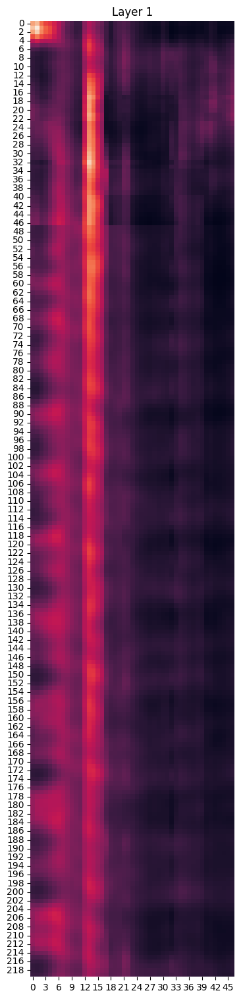

In [25]:
attn_output_weights = [t[0].squeeze() for t in encoder_sa[SAMPLE_IDX].values()]
fig, ax = plot_encoder_layers(
    attn_output_weights,
    hp,
    output_path,
    transparent=transparent_plot,
    src_padding_mask=src_padding_mask,
    figsize=(4, 30),
)

### Decoder Self-Attention

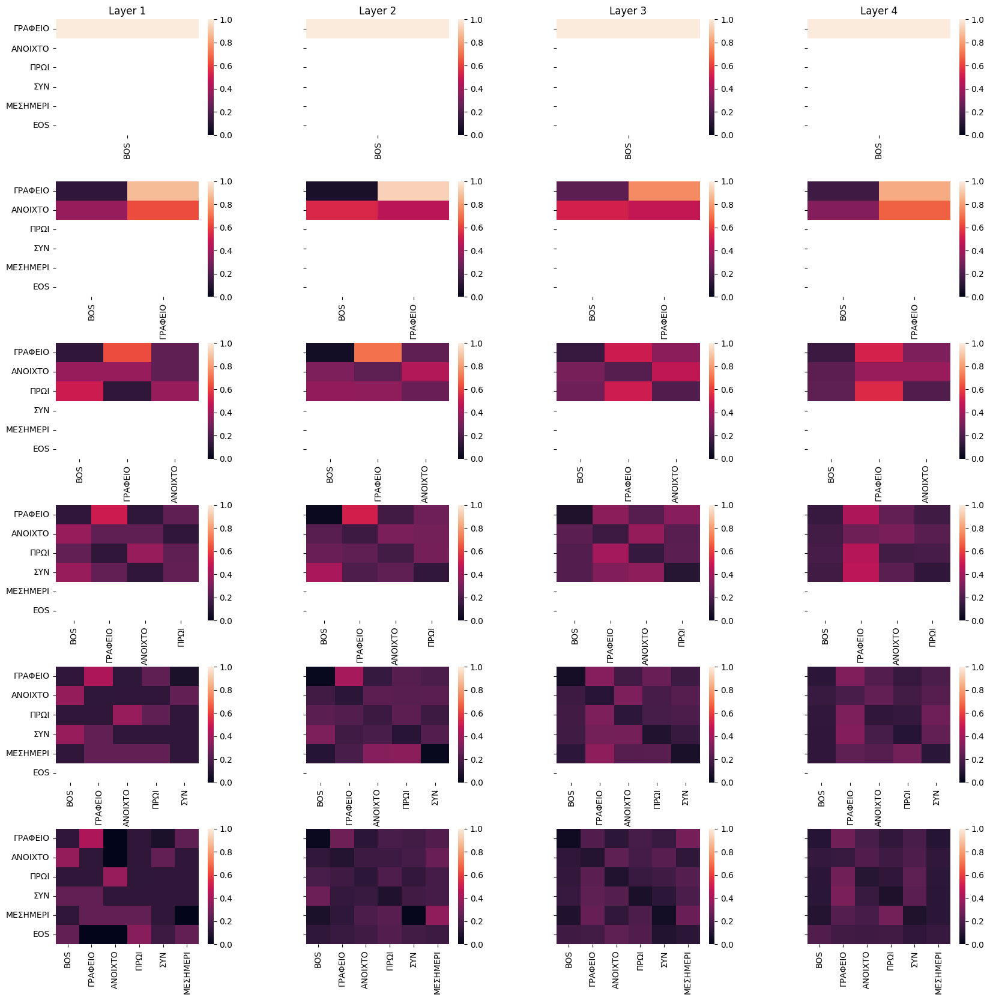

In [26]:
fig, ax = plot_decoder_layers(
    decoder_sa[SAMPLE_IDX],
    hp,
    translation,
    "self",
    output_path,
    transparent=transparent_plot,
)

### Decoder Cross-Attention

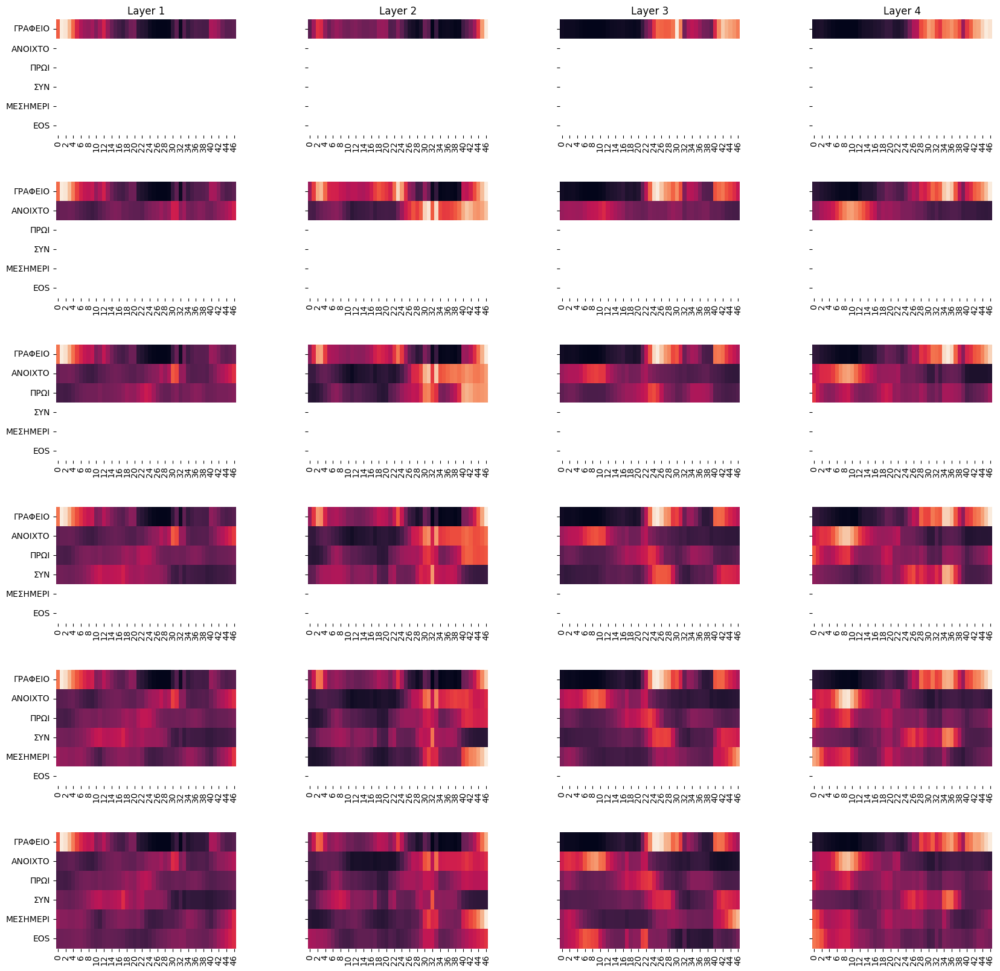

In [27]:
fig, ax = plot_decoder_layers(
    decoder_ca[SAMPLE_IDX],
    hp,
    translation,
    "cross",
    output_path,
    transparent=transparent_plot,
    src_padding_mask=src_padding_mask,
)

## Intermediate outputs

In [28]:
def reorganize_list(input_list, N):
    grouped_list = []
    for i in range(N):
        grouped_list.extend(input_list[i::N])
    return grouped_list


diff_sa_mha_block = [
    t1 - t2
    for t1, t2 in zip(
        intermediate_outputs[SAMPLE_IDX]["sa_block"],
        intermediate_outputs[SAMPLE_IDX]["mha_block"],
    )
]

tgt_length = len(translation) - 1  # from BOS to EOS-1
attn_output_weights_list = reorganize_list(diff_sa_mha_block, hp["NUM_DECODER_LAYERS"])
for i in range(0, len(attn_output_weights_list), tgt_length):
    print(f"Layer {i // tgt_length + 1}:")
    for j in range(i, i + tgt_length):
        w = attn_output_weights_list[j]
        print(f"{w.shape} → {w.mean():>7.3f}")

Layer 1:
(1, 128) →  -0.028
(2, 128) →  -0.026
(3, 128) →   0.081
(4, 128) →   0.170
(5, 128) →   0.059
(6, 128) →   0.215
Layer 2:
(1, 128) →   0.041
(2, 128) →   0.017
(3, 128) →  -0.012
(4, 128) →   0.009
(5, 128) →  -0.005
(6, 128) →  -0.006
Layer 3:
(1, 128) →   0.036
(2, 128) →  -0.012
(3, 128) →   0.006
(4, 128) →   0.006
(5, 128) →  -0.016
(6, 128) →  -0.008
Layer 4:
(1, 128) →   0.051
(2, 128) →  -0.033
(3, 128) →  -0.030
(4, 128) →  -0.022
(5, 128) →  -0.021
(6, 128) →  -0.021


## Visualize attention per word alongside video

### Static

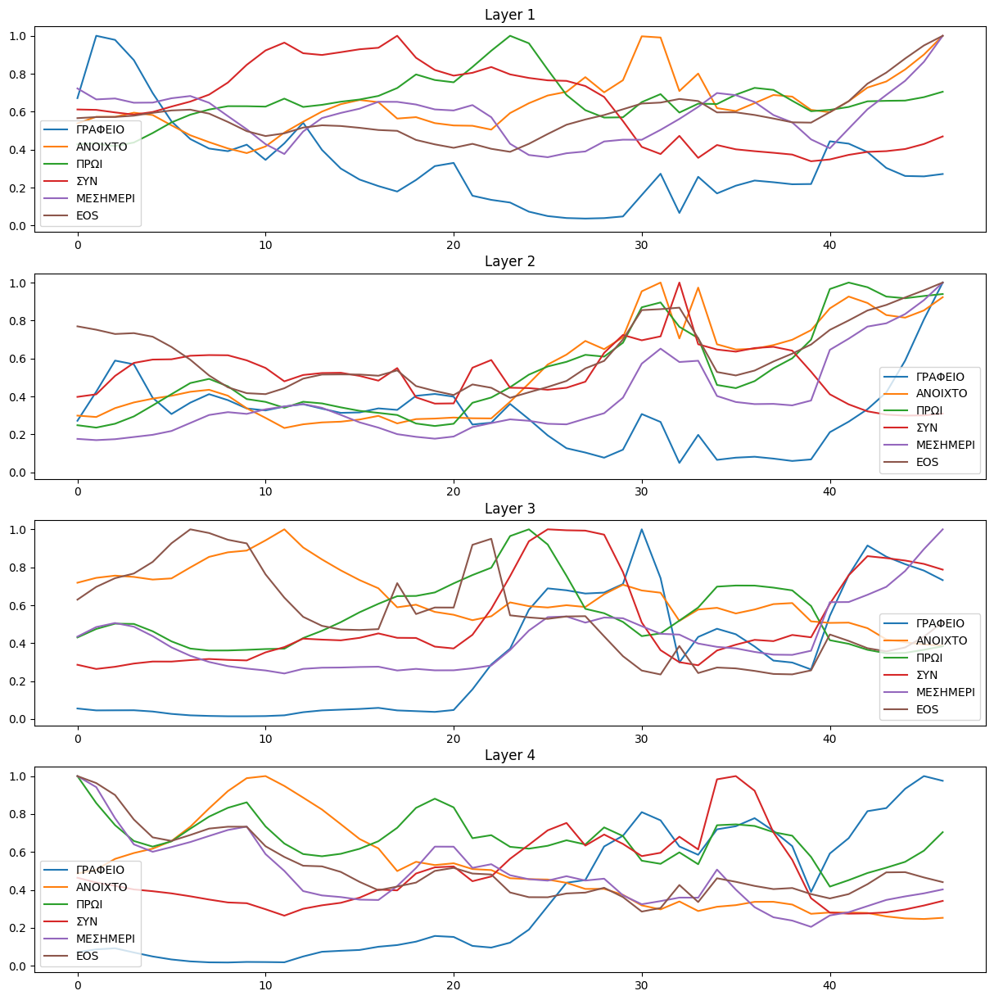

In [29]:
from interp.plot_functions import plot_decoder_attn_per_frame

attn_weights = plot_decoder_attn_per_frame(
    decoder_ca[SAMPLE_IDX],
    "lineplot",
    translation,
    src_padding_mask=src_padding_mask,
    output_path=output_path,
    transparent=transparent_plot,
    figsize=(15, 15),
)

### Animation

In [30]:
%matplotlib notebook

In [31]:
from interp.plot_functions import plot_decoder_attn_weights_bars


anim = plot_decoder_attn_weights_bars(
    src, decoder_ca[SAMPLE_IDX], hp, output_path, translation
)

<IPython.core.display.Javascript object>

In [32]:
HTML(anim.to_jshtml())